In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import cellspec as spc
import umap
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

%matplotlib inline

/home/dmullane/micromamba/envs/default_jupyter/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
colors = [
    '#FF1B5E',  # coral
    '#FFDB57',  # yellow
    '#438CFD',  # blue
    '#FF8C00',  # orange
    '#80F15E',  # lime green
    '#03FFFF',  # cyan
    '#5941A9',  # purple
    '#E980FC',  # magenta
    '#1A1A2E',  # navy
    '#F5F0FF',  # lavender white
    '#C17F3E',  # amber brown
]
extended_colors = [
    '#2E2A3A',
    '#FF8DAF', '#FF1B5E',
    '#FFEDA0', '#FFDB57',
    '#A4C8FE', '#438CFD',
    '#FFCF80', '#FF8C00',
    '#C4F9AE', '#80F15E',
    '#A0FFFF', '#03FFFF',
    '#A99FD4', '#5941A9',
    '#F4BFFE', '#E980FC',
    '#E8E4F0', '#C4BDD6',
    '#E8C89A', '#C17F3E'
]

In [3]:
import matplotlib.font_manager as fm
import os, glob


fm._load_fontmanager(try_read_cache=False)
# Register TeX Gyre Heros if present
for f in glob.glob(os.path.expanduser("~/.local/share/fonts/texgyreheros*.otf")):
    fm.fontManager.addfont(f)

In [4]:
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros"],
    "font.size": 12,

    "axes.linewidth": 2.5,
    # Tick marks
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,

    # Tick direction (outward is common in publications)
    "xtick.direction": "out",
    "ytick.direction": "out",
})

In [5]:
import anndata

In [6]:
adata = anndata.read_h5ad('../results/worm6_final/DNA_analysis/joint_variants_process.h5ad')

In [7]:
### Helper functions:
def plot_depth(adata, BINS=100, COLOR=colors[2], title=''):
    f, ax = plt.subplots(figsize=(7, 5))
    sns.despine(f)
    sns.histplot(adata.var, x='bulk_dp', 
                 alpha=0.75,
                 color = COLOR,
                 linewidth=1,
                 ax=ax,
                 log_scale=True,
                 bins=100
                )

    ax.set_yscale('log')
    plt.xlabel("Depth in bulk", fontsize=20)
    plt.ylabel("Count of Sites", fontsize=20)
    plt.title(title, fontsize=20)
    ax.tick_params(labelsize=18)
    
    plt.show()
    return f


def plot_vaf(adata, BINS=100, COLOR=colors[2], title='', XLOG=False, YLOG=True):
    f, ax = plt.subplots(figsize=(7, 5))
    sns.despine(f)
    sns.histplot(adata.var, x='bulk_vaf', 
                 alpha=0.75,
                 color = COLOR,
                 linewidth=1,
                 ax=ax,
                 log_scale=XLOG,
                 bins=BINS
                )
    if YLOG==True:
        ax.set_yscale('log')
    
    plt.xlabel("VAF in bulk", fontsize=20)
    plt.ylabel("Count of Sites", fontsize=20)
    ax.tick_params(labelsize=18)
    plt.title(title, fontsize=20)
    plt.show()
    return f

/loc/scratch/8669588/ipykernel_26666/3059259029.py:1: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  donors = adata.obs.donor.unique().sort_values().to_list()


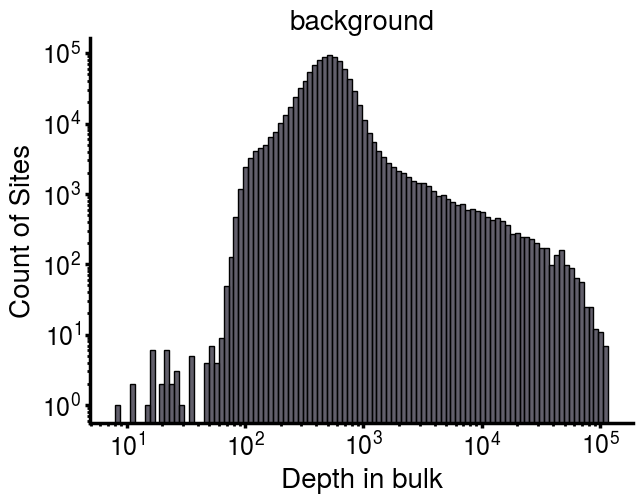

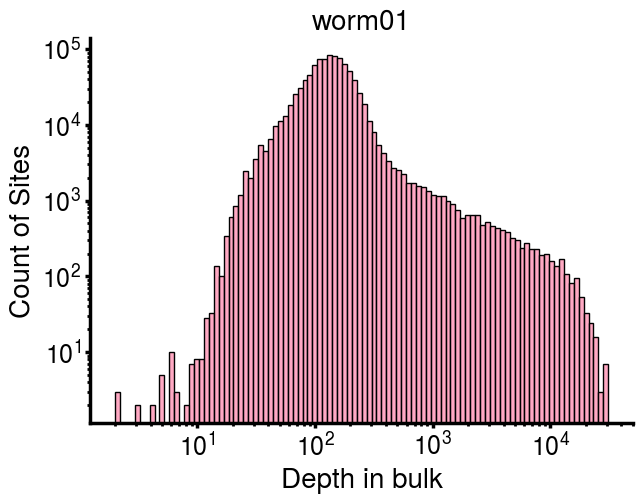

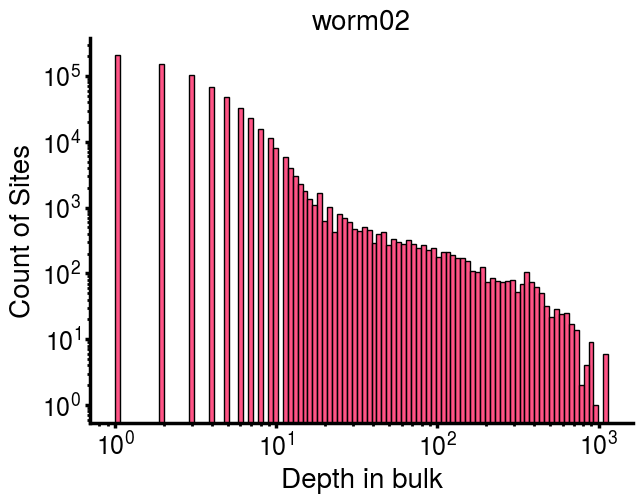

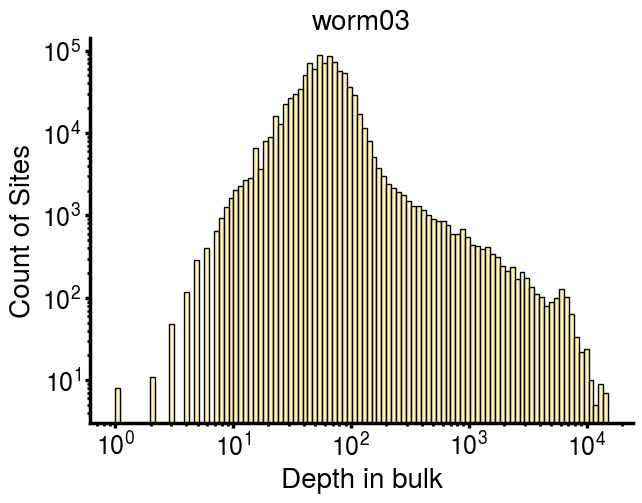

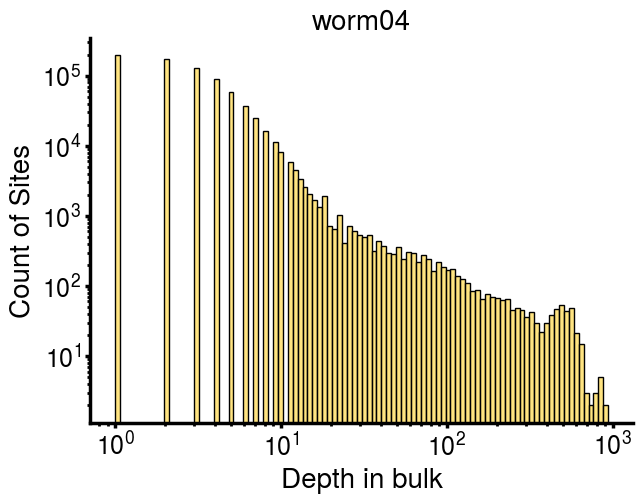

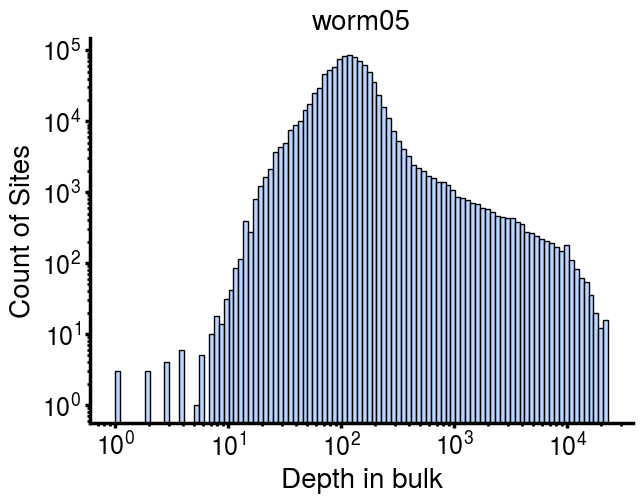

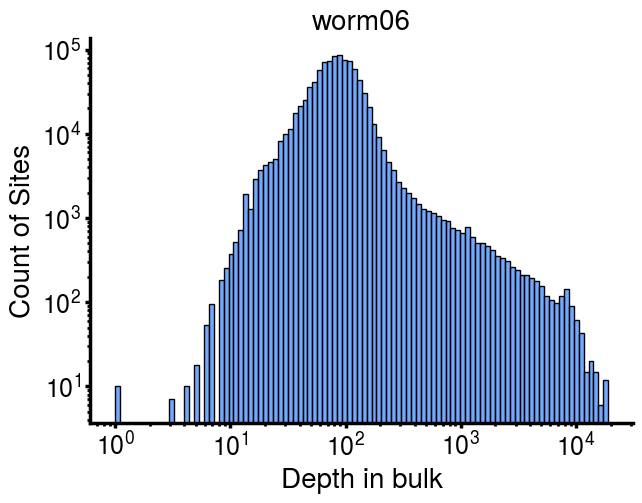

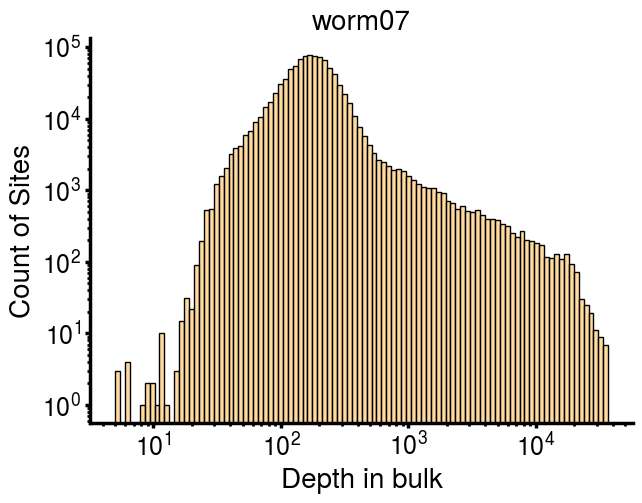

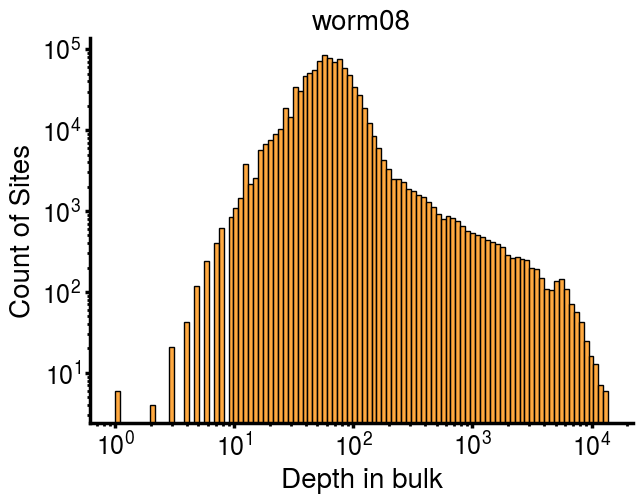

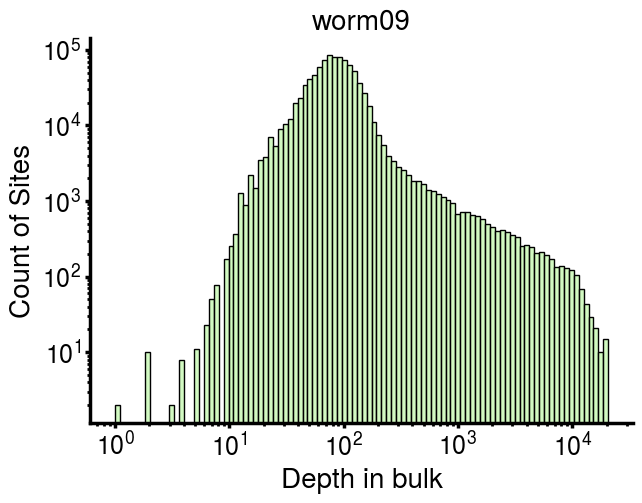

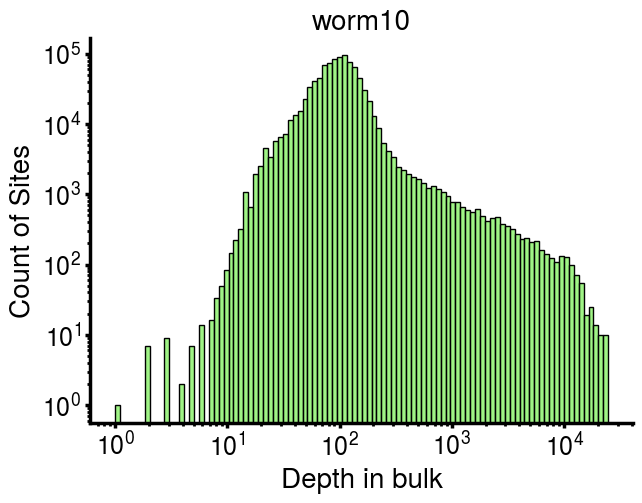

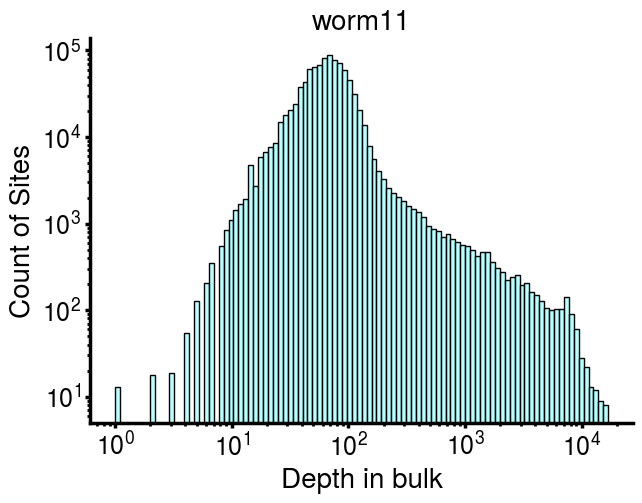

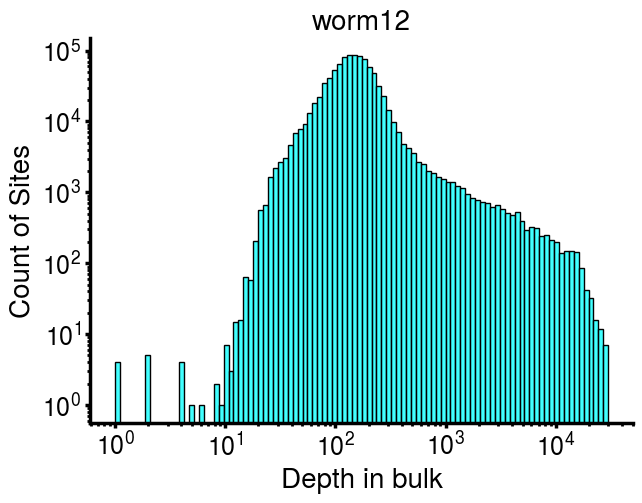

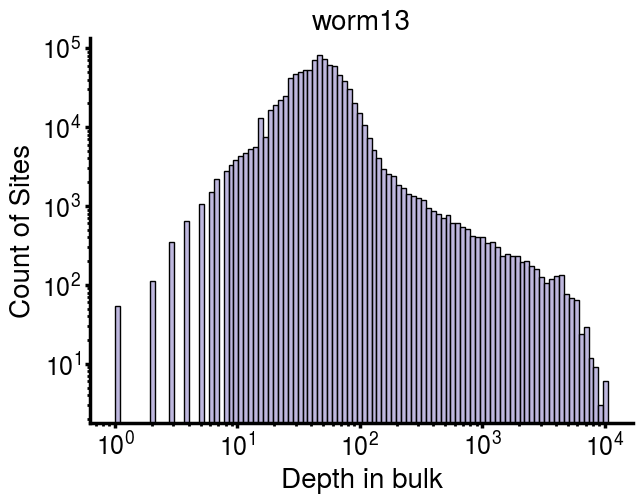

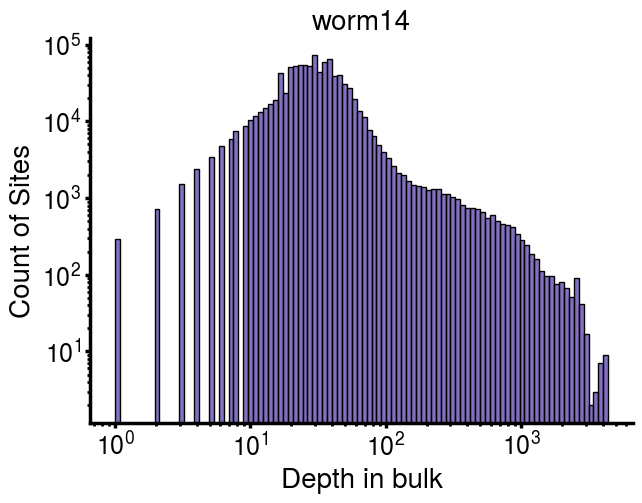

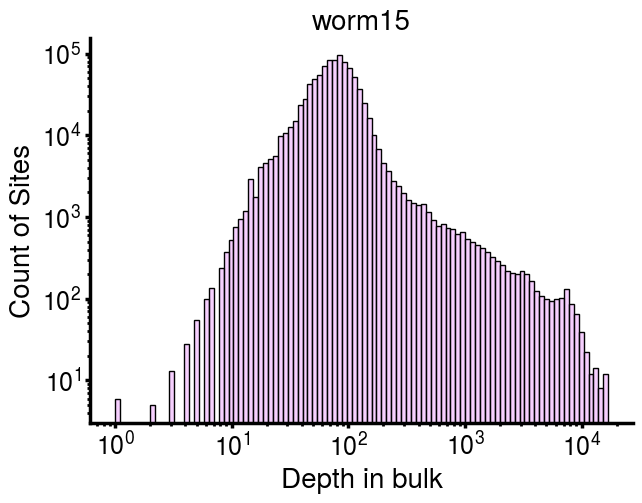

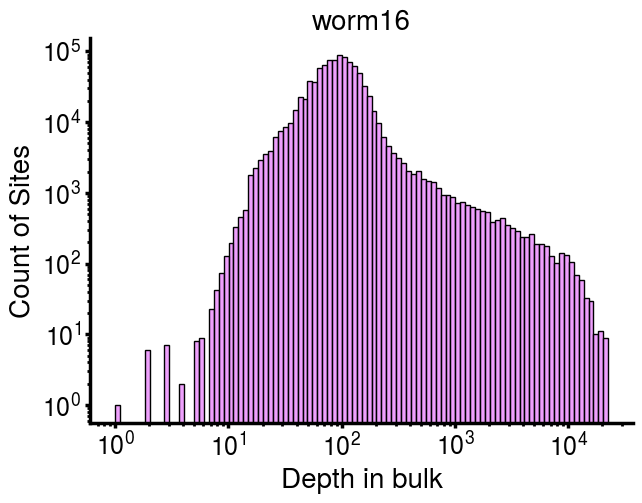

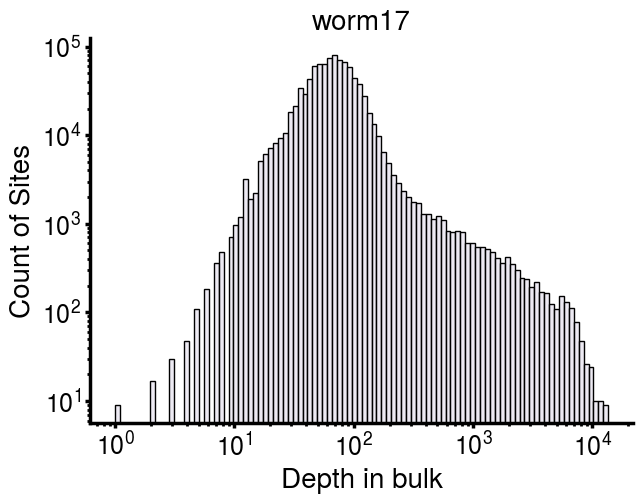

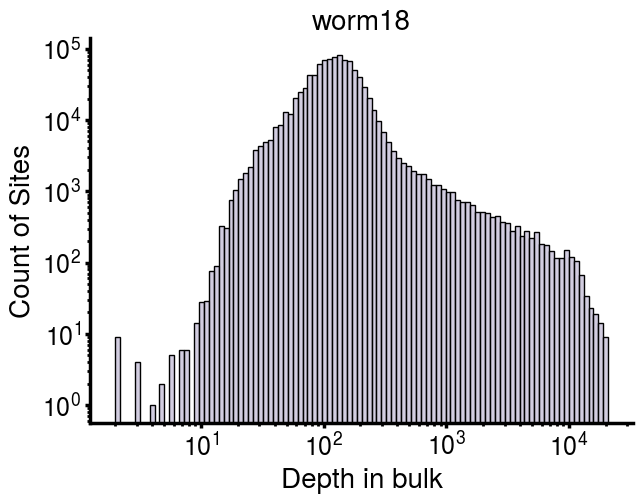

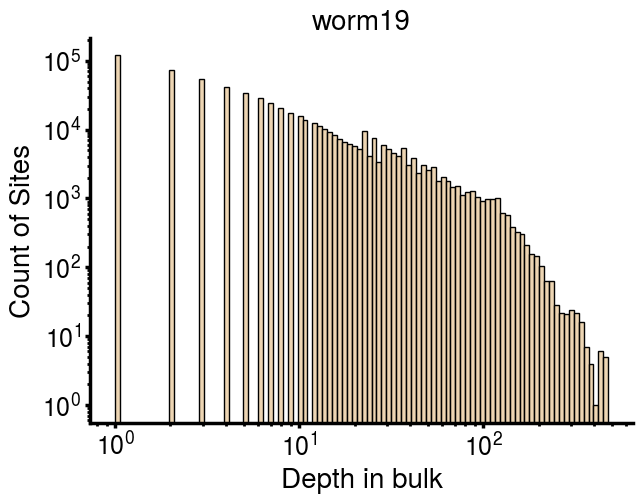

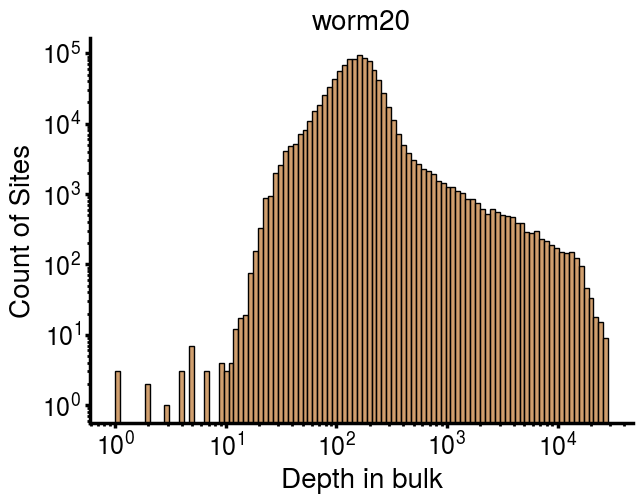

In [8]:
donors = adata.obs.donor.unique().sort_values().to_list()

for n,d in enumerate(donors):
    sub = adata[adata.obs['donor']==d].copy()
    sub.var['bulk_dp'] = np.ravel(sub.layers['DP'].sum(axis=0))
    
    plot_depth(sub, COLOR=extended_colors[n], title=d)

/loc/scratch/8669588/ipykernel_26666/3700131020.py:1: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  donors = adata.obs.donor.unique().sort_values().to_list()


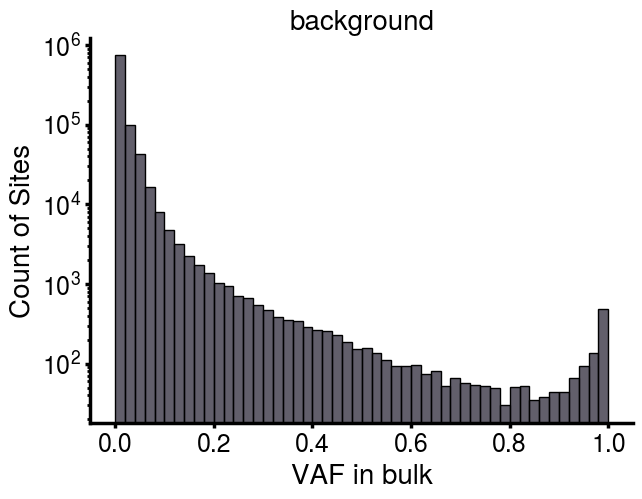

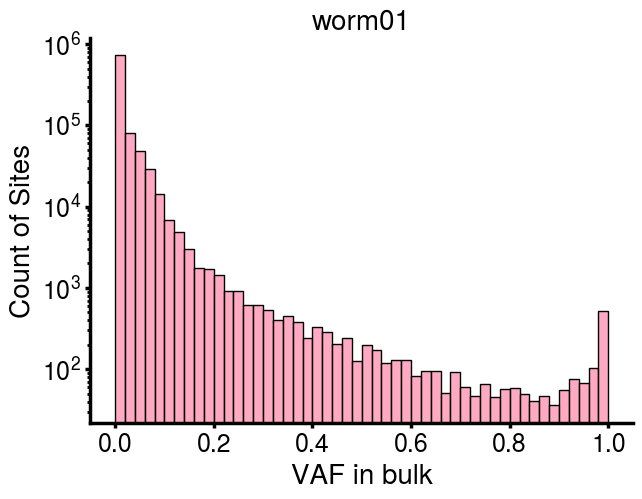

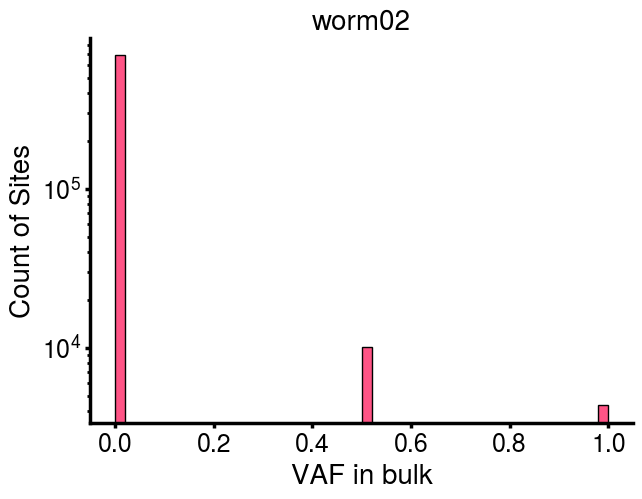

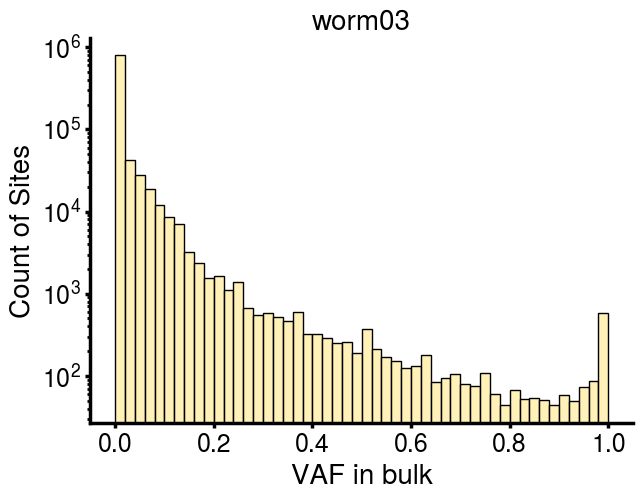

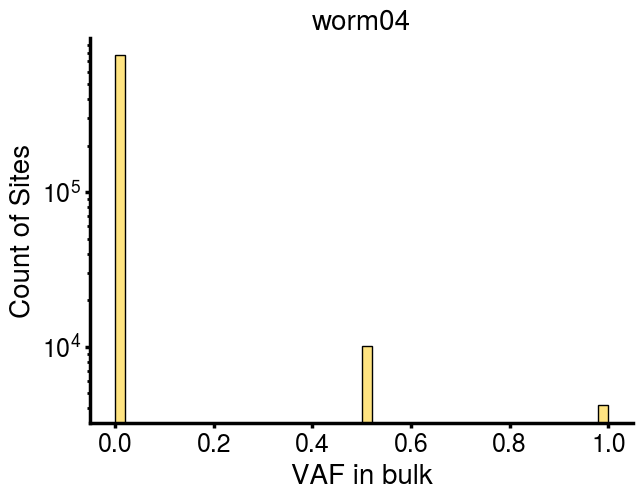

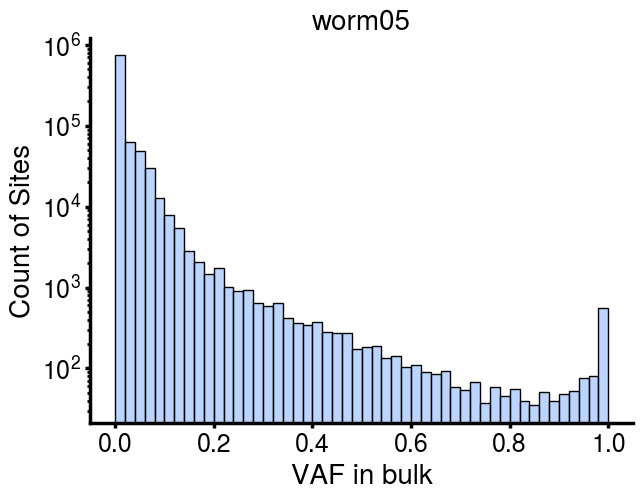

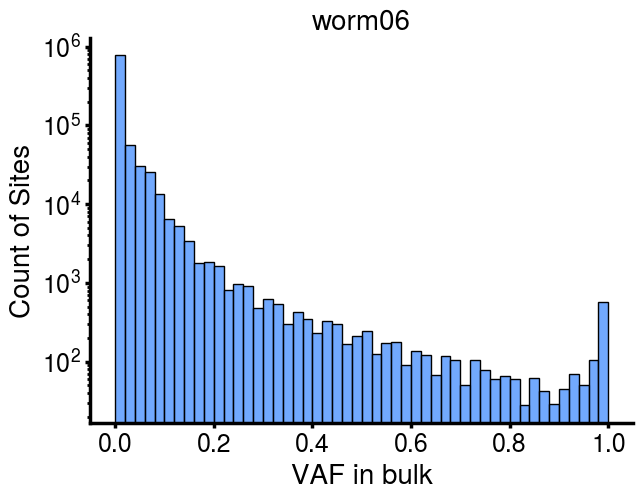

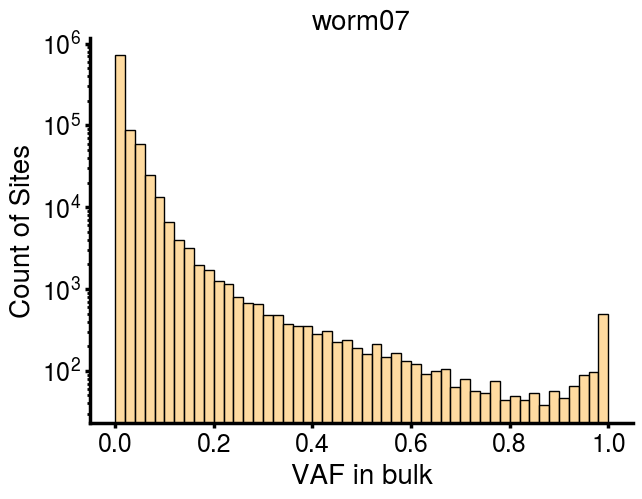

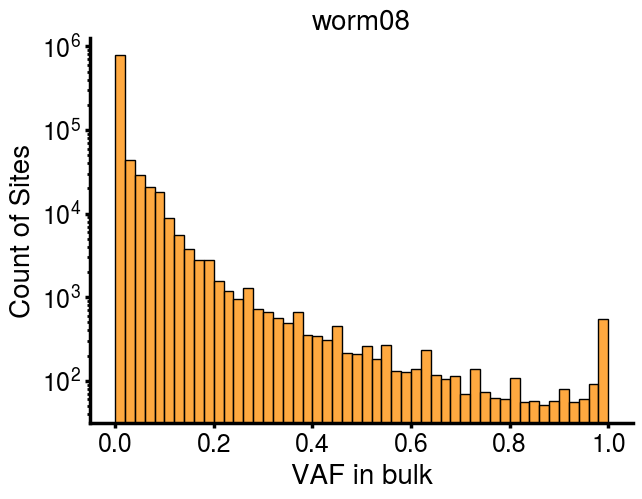

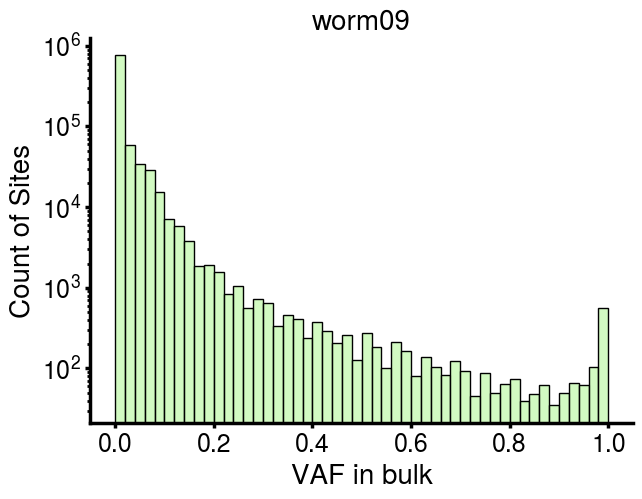

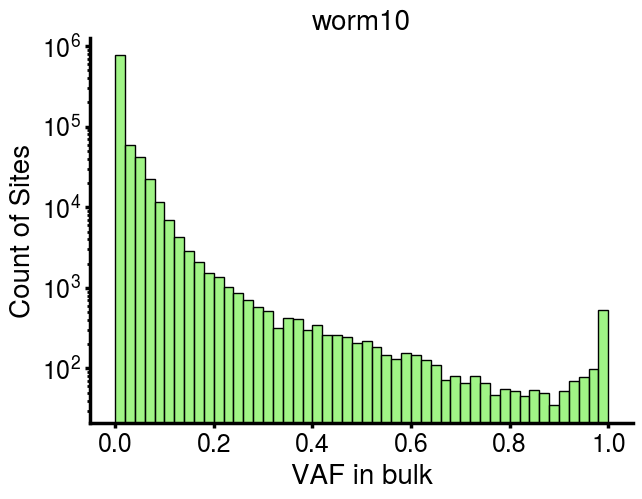

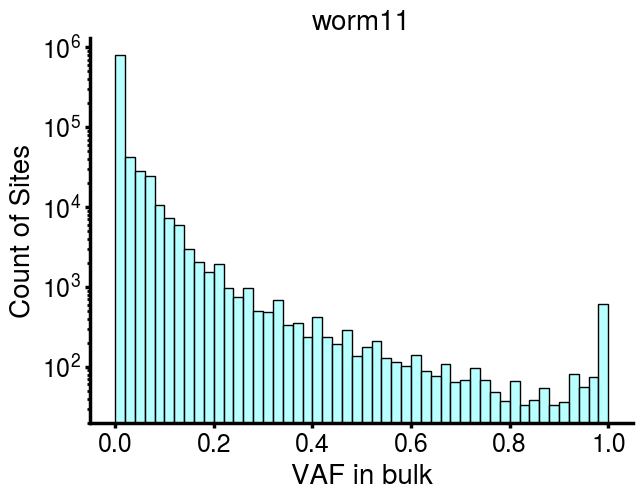

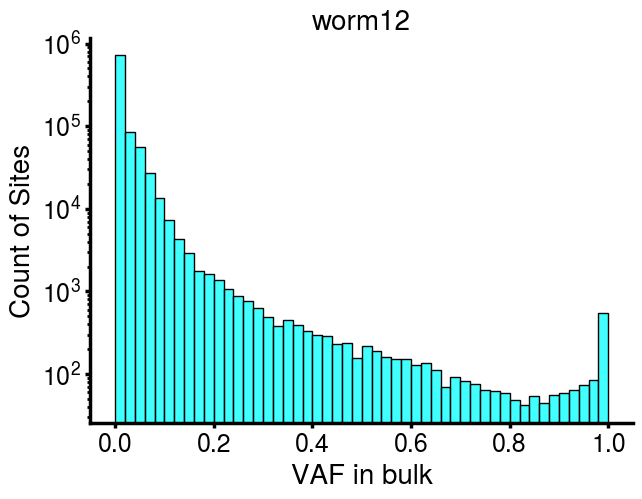

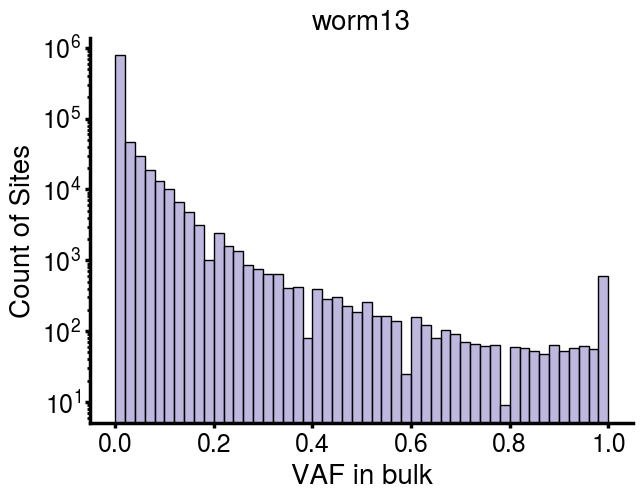

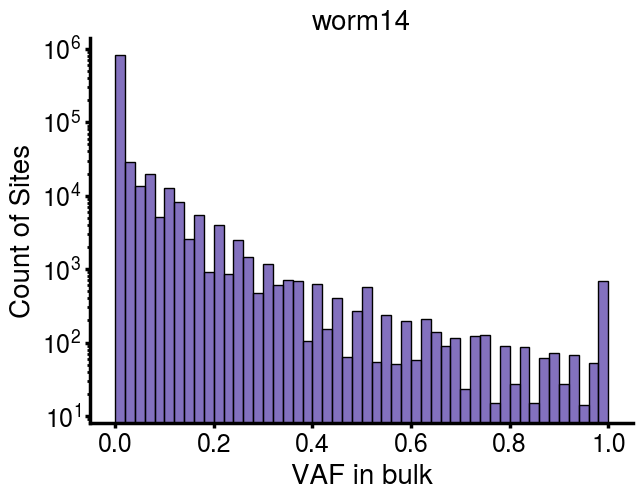

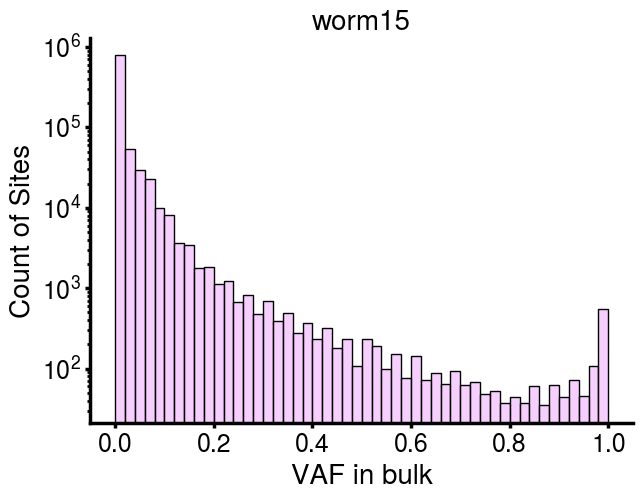

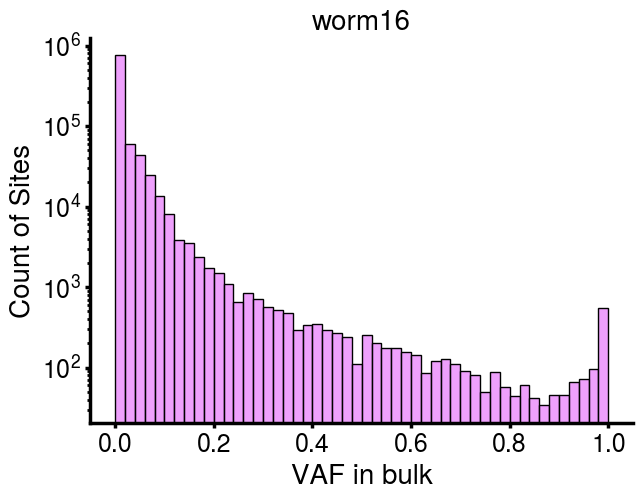

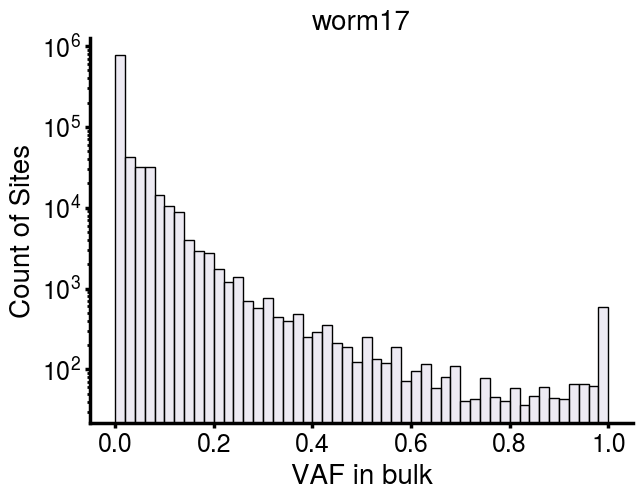

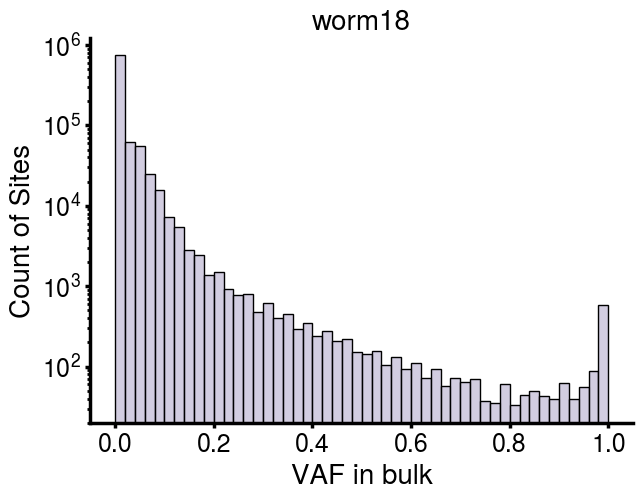

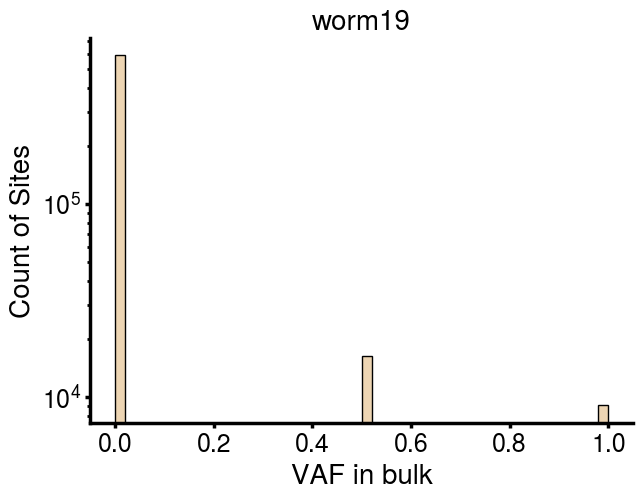

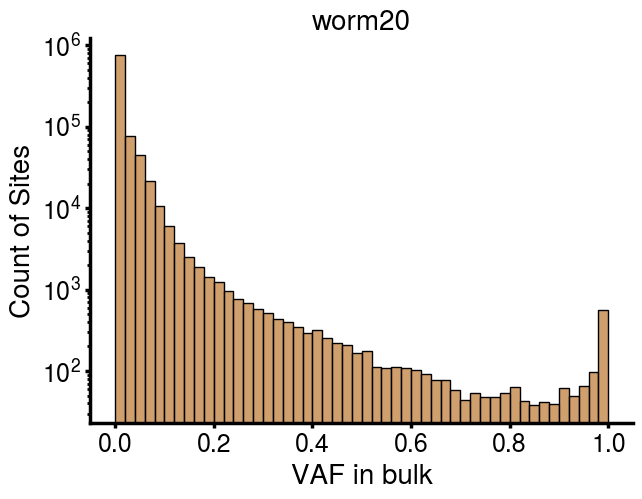

In [9]:
donors = adata.obs.donor.unique().sort_values().to_list()

for n,d in enumerate(donors):
    sub = adata[adata.obs['donor']==d].copy()
    sub.var['bulk_dp'] = np.ravel(sub.layers['DP'].sum(axis=0))
    med = np.int64(sub.var['bulk_dp'].median())
    spc.tl.compute_bulk_vaf(sub,
                        # target_dp=int(adata.var['bulk_dp'].median())
                        target_dp=med
                       )
    plot_vaf(sub, BINS=50, COLOR=extended_colors[n], title=d)